### **Autor:** David Roca Tauste
---

# 📌 **ACTIVIDAD 2: MODELO DE REGRESIÓN LOGÍSTICA**
---

## PASO 1: CARGA DE DATOS Y CREACIÓN DEL MODELO

### a) Usa este código en el fichero saa_u02_p04_a2_<tus_iniciales>.py (o notebook) para cargar los datos y completa el resto de apartados. Pero cuando particiones los datos y realices otras operaciones donde intervenga el azar añade una semilla aleatoria para que el proceso sea repetible (que coja los mismos datos, que evolucione igual, etc.):

In [225]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df_vino = pd.read_csv("wine.csv", header=None)

df_vino.columns = [
    "Class",
    "Alcohol",
    "Ácido Málico",
    "Posos",
    "Alcalinidad de posos",
    "Magnesio",
    "Total Fenoles",
    "Flavanoides",
    "No flavanoides fenoles",
    "Proanticianinas",
    "Intensidad Color",
    "Saturación",
    "OD280/OD315 de vinos diluidos",
    "Prolina",
]

print("Clases", np.unique(df_vino["Class"]))
print(df_vino.head())

# Dividir en train + test
X, y = df_vino.iloc[:, 1:].values, df_vino.iloc[:, 0].values

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=semilla
)

Clases [1 2 3]
   Class  Alcohol  Ácido Málico  Posos  Alcalinidad de posos  Magnesio  \
0      1    14.23          1.71   2.43                  15.6       127   
1      1    13.20          1.78   2.14                  11.2       100   
2      1    13.16          2.36   2.67                  18.6       101   
3      1    14.37          1.95   2.50                  16.8       113   
4      1    13.24          2.59   2.87                  21.0       118   

   Total Fenoles  Flavanoides  No flavanoides fenoles  Proanticianinas  \
0           2.80         3.06                    0.28             2.29   
1           2.65         2.76                    0.26             1.28   
2           2.80         3.24                    0.30             2.81   
3           3.85         3.49                    0.24             2.18   
4           2.80         2.69                    0.39             1.82   

   Intensidad Color  Saturación  OD280/OD315 de vinos diluidos  Prolina  
0              5.64  

### b) Crea un objeto multiclass.OneVsRestClassifier(LogisticRegression(..)) para que utilice el método uno contra el resto y el solver ‘liblinear’ (tienes ejemplos en la unidad, aunque en las nuevas versiones de scikit-learn el parámetro multi_class='ovr' del método fit() de LogisticRegression está marcado como deprecated), por este motivo te pido que uses esta nueva clase. Debes pasarle un objeto estimador que en este caso es uno de regresión logística. Puedes acceder a ellos a través de objeto_ovr.estimators_.

In [226]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Mdelo OneVsRestClassifier con LogisticRegression
modelo_ovr = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=semilla))
modelo_ovr.fit(X_train, y_train)

print("Clasificadores individuales:", modelo_ovr.estimators_)

Clasificadores individuales: [LogisticRegression(random_state=546, solver='liblinear'), LogisticRegression(random_state=546, solver='liblinear'), LogisticRegression(random_state=546, solver='liblinear')]


### c) Imprime los atributos intercept_ y coef_ del modelo Lineal ¿Qué estás imprimiendo?
Estos valores son los términos independientes y coeficientes de cada modelo de regresión logística dentro del modelo "OneVsRestClassifier".

In [227]:
for i, estimator in enumerate(modelo_ovr.estimators_):
    print(f"\nCLASE {i+1}:")
    print(f"Intercept de la clase: {estimator.intercept_}")
    print(f"Coeficientes de la clase: {estimator.coef_}")


CLASE 1:
Intercept de la clase: [-0.25944384]
Coeficientes de la clase: [[-0.72477518  0.31708019  1.2353533  -0.47162105 -0.03402736  0.47745903
   1.01974052  0.0646753  -0.32695099 -0.044519   -0.20085785  0.89580144
   0.01670956]]

CLASE 2:
Intercept de la clase: [0.34843521]
Coeficientes de la clase: [[ 0.79974762 -0.97926406 -0.84719204  0.26254209  0.01523248 -0.07201561
   0.36957116  0.39222577  0.64786808 -1.56642056  0.85214233  0.2104813
  -0.01404971]]

CLASE 3:
Intercept de la clase: [-0.04830035]
Coeficientes de la clase: [[-2.60322735e-01  4.60543156e-01 -6.34383826e-03  1.25069028e-01
   1.47141601e-02 -6.43632399e-01 -1.67990221e+00 -1.18324155e-01
  -5.93204207e-01  9.35980611e-01 -4.97152035e-01 -1.19036825e+00
   4.01513553e-04]]


### e) Entrena el modelo y muestra los valores de la matriz de confusión y las métricas de eficiencia (accuracy, recall positivo y negativo, sensitivity y F1-score) o alternativamente un informe de clasificación donde aparezcan.

In [228]:
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones
y_pred = modelo_ovr.predict(X_test)

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(matriz)

# Métricas de eficiencia
clases = np.unique(y_test).astype(str)
reporte = classification_report(y_test, y_pred, target_names=clases)
print("\nInforme de clasificación:\n", reporte)


Matriz de confusión:
[[10  0  0]
 [ 1 21  0]
 [ 0  0 22]]

Informe de clasificación:
               precision    recall  f1-score   support

           1       0.91      1.00      0.95        10
           2       1.00      0.95      0.98        22
           3       1.00      1.00      1.00        22

    accuracy                           0.98        54
   macro avg       0.97      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



### f) Muestra la curva ROC y el valor AUC de cada clase y del modelo en global. Para hacerlo, hay que binarizar las predicciones (generando una columna con valores 0/1 para las predicciones de cada clase) y obtener los scores (distancia de cada predicción a cada clase) con la función decision_function(). Como posiblemente sea complicado, te paso el código para que lo añadas a tu programa y respondas ¿En qué clase obtiene mejor y peor resultado?

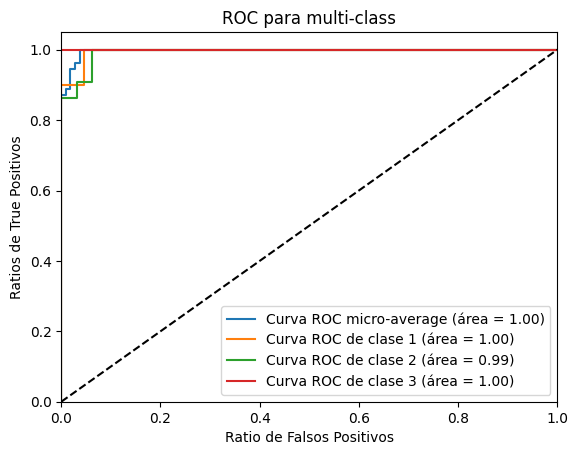

In [229]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

fpr = dict()
tpr = dict()
roc_auc = dict()

clases = df_vino["Class"].unique()  # Diferentes clases: diferentes valores de Class
n_clases = clases.shape[0]  # Cantidad de clases diferentes

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])  # Binarizar el test
y_score = modelo_ovr.decision_function(X_test)  # Distancia a cada clase

for i in range(n_clases):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())  # micro-medias ROC y AUC
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Dibujar la curva ROC
plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="Curva ROC micro-average (área = {0:0.2f})".format(roc_auc["micro"]),
)
for i in range(n_clases):
    plt.plot(
        fpr[i],
        tpr[i],
        label="Curva ROC de clase {0} (área = {1:0.2f})".format(clases[i], roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Ratio de Falsos Positivos")
plt.ylabel("Ratios de True Positivos")
plt.title("ROC para multi-class")
plt.legend(loc="lower right")
plt.show()

Obtiene un mejor resultado en las clases 1 y 3 (1'0) y un peor resultado en la clase 2 (0'99).

---
## PASO 2: MEJORAR MODELO

### MEJORAR DATOS QUE ALIMENTAN AL ALGORITMO/MODELO

### g) ¿Qué significa estratificar los datos al hacer la división en train + test? Añade en la llamada al método de particionar en train y test el parámetro stratify=y.
Estratificar los datos significa asegurarse de que la proporción de clases en ambos conjuntos sea similar a la distribución original en el dataset completo. "stratify=y" garantiza que la división mantenga la distribución de clases de y.

In [230]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=semilla, stratify=y
)

### h) Utiliza un objeto StandardScaler para estandarizar los datos de train y test antes de entrenar. ¿Porqué es interesante estandarizar los datos?

In [231]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train.astype(np.float64))
X_test_escalado = scaler.transform(X_test.astype(np.float64))

### USAR REGULARIZACIÓN L1

### i) Indica que quieres usar regularización de tipo ℓ1 y deja el parámetro C= 1.0 ¿Qué ocurre si lo bajas, aumenta o disminuye la fuerza de la regularización?

In [232]:
modelo_ovr = OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=semilla))
modelo_ovr.fit(X_train, y_train)

OneVsRestClassifier(estimator=LogisticRegression(penalty='l1', random_state=546,
                                                 solver='liblinear'))

### j) Vuelve a imprimir los coeficientes y los puntos de intercepción.

In [233]:
for i, estimator in enumerate(modelo_ovr.estimators_):
    print(f"\nCLASE {i+1}:")
    print(f"Intercept: {estimator.intercept_}")
    print(f"Coeficientes: {estimator.coef_}")


CLASE 1:
Intercept: [0.]
Coeficientes: [[-0.37099257  0.66760976  0.         -0.56433361 -0.04333208  0.
   1.22063226  0.          0.         -0.054563    0.          0.78061348
   0.01660813]]

CLASE 2:
Intercept: [0.]
Coeficientes: [[ 0.72154449 -1.30152988 -0.12032068  0.26324576  0.03186243  0.
   0.55674622  0.          0.47797988 -1.57816881  0.          0.
  -0.01365505]]

CLASE 3:
Intercept: [0.]
Coeficientes: [[-9.58822706e-02  5.08867761e-01  0.00000000e+00  8.69258756e-03
  -2.11942897e-02  0.00000000e+00 -3.79090687e+00  0.00000000e+00
   0.00000000e+00  1.20228482e+00  0.00000000e+00  0.00000000e+00
   3.56196190e-04]]


### k) Como hemos usado una regularización de tipo ℓ1, nos habrá anulado las características menos importantes. Vamos a aprovechar esto para mostrarlas ordenadas de mayor a menor importancia. Haz un listado por consola donde aparezca el nombre de la característica, su importancia con 4 decimales y la importancia acumulada (la suma de importancias desde la más a la menos importante, una especie de ratio de importancia si usamos desde la primera hasta la actual).

In [234]:
# Importancia de características
importancias = np.mean(np.abs([est.coef_ for est in modelo_ovr.estimators_]), axis=0).flatten()
nombre_caracteristicas = df_vino.columns[1:]

# Características por importancia
indices_ordenados = np.argsort(importancias)[::-1]
importancia_acumulada = 0
i = 0

print("\nCaracterísticas ordenadas por importancia:")
for indice in indices_ordenados:
    importancia_acumulada += importancias[indice]
    print(f"{i}) {nombre_caracteristicas[indice]}: {importancias[indice]:.4f}, Acumulada: {importancia_acumulada:.4f}")

    i += 1


Características ordenadas por importancia:
0) Flavanoides: 1.8561, Acumulada: 1.8561
1) Intensidad Color: 0.9450, Acumulada: 2.8011
2) Ácido Málico: 0.8260, Acumulada: 3.6271
3) Alcohol: 0.3961, Acumulada: 4.0232
4) Alcalinidad de posos: 0.2788, Acumulada: 4.3020
5) OD280/OD315 de vinos diluidos: 0.2602, Acumulada: 4.5622
6) Proanticianinas: 0.1593, Acumulada: 4.7215
7) Posos: 0.0401, Acumulada: 4.7616
8) Magnesio: 0.0321, Acumulada: 4.7938
9) Prolina: 0.0102, Acumulada: 4.8040
10) Saturación: 0.0000, Acumulada: 4.8040
11) Total Fenoles: 0.0000, Acumulada: 4.8040
12) No flavanoides fenoles: 0.0000, Acumulada: 4.8040


### l) Y hacemos un gráfico de barras además de imprimir los valores. El resultado aproximado que se debería obtener:
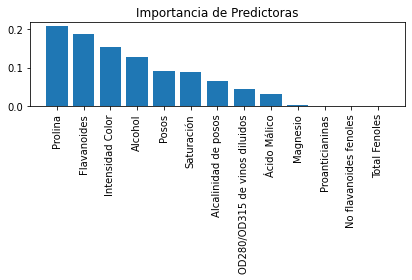

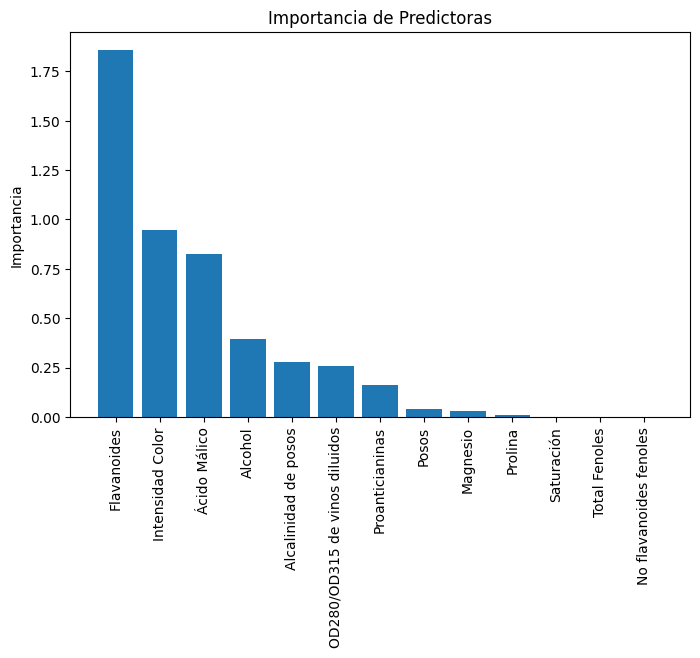

In [235]:
plt.figure(figsize=(8, 5))
plt.bar(range(len(indices_ordenados)), importancias[indices_ordenados], align="center")
plt.xticks(
    range(len(indices_ordenados)),
    nombre_caracteristicas[indices_ordenados],
    rotation=90,
)
plt.ylabel("Importancia")
plt.title("Importancia de Predictoras")
plt.show()

### m) Ahora elimina las características predictoras que se te han quedado con cero influencia y compara el desempeño de los dos modelos. ¿Hay diferencias significativas?


Desempeño del modelo original:
              precision    recall  f1-score   support

           1       1.00      0.94      0.97        18
           2       0.88      1.00      0.93        21
           3       1.00      0.87      0.93        15

    accuracy                           0.94        54
   macro avg       0.96      0.94      0.94        54
weighted avg       0.95      0.94      0.94        54


Desempeño del modelo con características filtradas:
              precision    recall  f1-score   support

           1       1.00      0.94      0.97        18
           2       0.91      1.00      0.95        21
           3       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



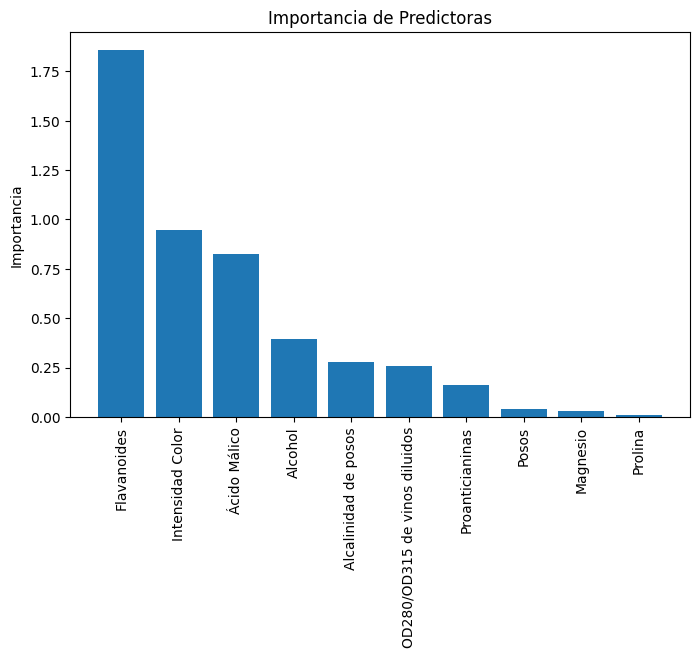

In [236]:
# Características con importancia mayor a 0
importancias = importancias[importancias > 0]
indices_filtrados = np.where(importancias)[0]
X_train_filtrado = X_train[:, indices_filtrados]
X_test_filtrado = X_test[:, indices_filtrados]
nombre_caracteristicas_filtrado = nombre_caracteristicas[indices_filtrados]

# Modelo con características filtradas
modelo_ovr_filtrado = OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=semilla))
modelo_ovr_filtrado.fit(X_train_filtrado, y_train)

# Desempeño de ambos modelos
y_pred_original = modelo_ovr.predict(X_test)
y_pred_filtrado = modelo_ovr_filtrado.predict(X_test_filtrado)

print("\nDesempeño del modelo original:")
print(classification_report(y_test, y_pred_original))

print("\nDesempeño del modelo con características filtradas:")
print(classification_report(y_test, y_pred_filtrado))

# Gráfico de barras
nombre_caracteristicas_filtradas = nombre_caracteristicas[indices_ordenados][:-3]
indices_ordenados = np.argsort(importancias)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(indices_ordenados)), importancias[indices_ordenados], align='center')
plt.xticks(range(len(indices_ordenados)), nombre_caracteristicas_filtradas, rotation=90)
plt.ylabel('Importancia')
plt.title('Importancia de Predictoras')
plt.show()

Es cierto que el desempeño del modelo sin las características con cero influencia es más preciso, sin embargo, no hay una gran diferencia en los resultados. Por ejemplo, respecto al macro avg la mejora ha sido de un 0'02 en "recall" y "f1-score" y de un 0'01 en "precision".